In [1]:
# Module 2 — Matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Our Jaipur zone data
df = pd.DataFrame({
    "zone":       ["Walled City", "Johari Bazaar", "Sindhi Camp", 
                   "Civil Lines", "Mansarovar"],
    "lst":        [48.2, 46.8, 44.1, 41.3, 38.7],
    "ndvi":       [0.143, 0.120, 0.161, 0.273, 0.429],
    "risk":       ["CRITICAL", "HIGH", "HIGH", "MEDIUM", "LOW"],
    "population": [87000, 54000, 38000, 29000, 15000],
    "impervious": [94, 89, 76, 58, 42],
})

print("Data loaded")
print(df.shape)

Data loaded
(5, 6)


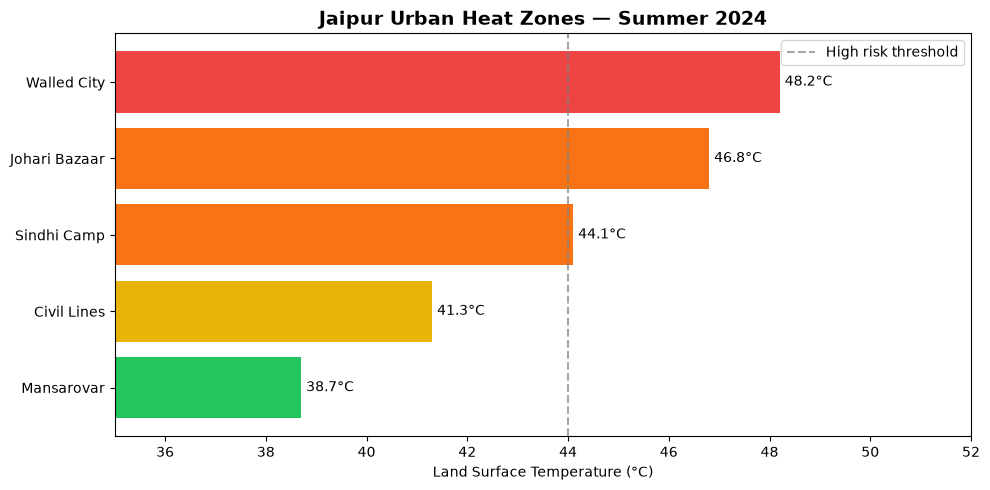

Chart saved


In [2]:
# Lesson 1 — Bar Chart: LST by Zone

fig, ax = plt.subplots(figsize=(10, 5))

# Colors based on risk level
colors = ["#EF4444", "#F97316", "#F97316", "#EAB308", "#22C55E"]

bars = ax.barh(df["zone"], df["lst"], color=colors)

# Add value labels on each bar
for bar, val in zip(bars, df["lst"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val}°C", va="center", fontsize=10)

# Styling
ax.set_xlabel("Land Surface Temperature (°C)")
ax.set_title("Jaipur Urban Heat Zones — Summer 2024", 
             fontsize=14, fontweight="bold")
ax.set_xlim(35, 52)
ax.axvline(x=44, color="gray", linestyle="--", alpha=0.7, label="High risk threshold")
ax.legend()
ax.invert_yaxis()  # hottest zone at top

plt.tight_layout()
plt.savefig("lst_by_zone.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

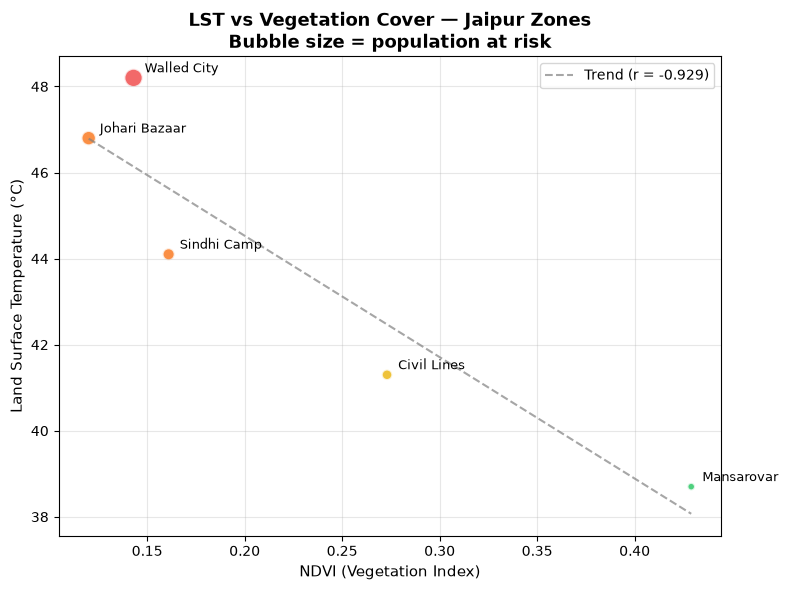

Chart saved


In [3]:
# Lesson 2 — Scatter Plot: NDVI vs LST

fig, ax = plt.subplots(figsize=(8, 6))

# Color each point by risk
risk_colors = {
    "CRITICAL": "#EF4444",
    "HIGH":     "#F97316",
    "MEDIUM":   "#EAB308",
    "LOW":      "#22C55E"
}
colors = [risk_colors[r] for r in df["risk"]]

# Scatter plot — size of dot = population
scatter = ax.scatter(
    df["ndvi"],
    df["lst"],
    c=colors,
    s=df["population"]/500,  # bubble size
    alpha=0.8,
    edgecolors="white",
    linewidth=1.5
)

# Label each point
for _, row in df.iterrows():
    ax.annotate(
        row["zone"],
        (row["ndvi"], row["lst"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9
    )

# Add trend line
z = np.polyfit(df["ndvi"], df["lst"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["ndvi"].min(), df["ndvi"].max(), 100)
ax.plot(x_line, p(x_line), "gray", linestyle="--", 
        alpha=0.7, label=f"Trend (r = -0.929)")

# Styling
ax.set_xlabel("NDVI (Vegetation Index)", fontsize=11)
ax.set_ylabel("Land Surface Temperature (°C)", fontsize=11)
ax.set_title("LST vs Vegetation Cover — Jaipur Zones\n"
             "Bubble size = population at risk", 
             fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lst_vs_ndvi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

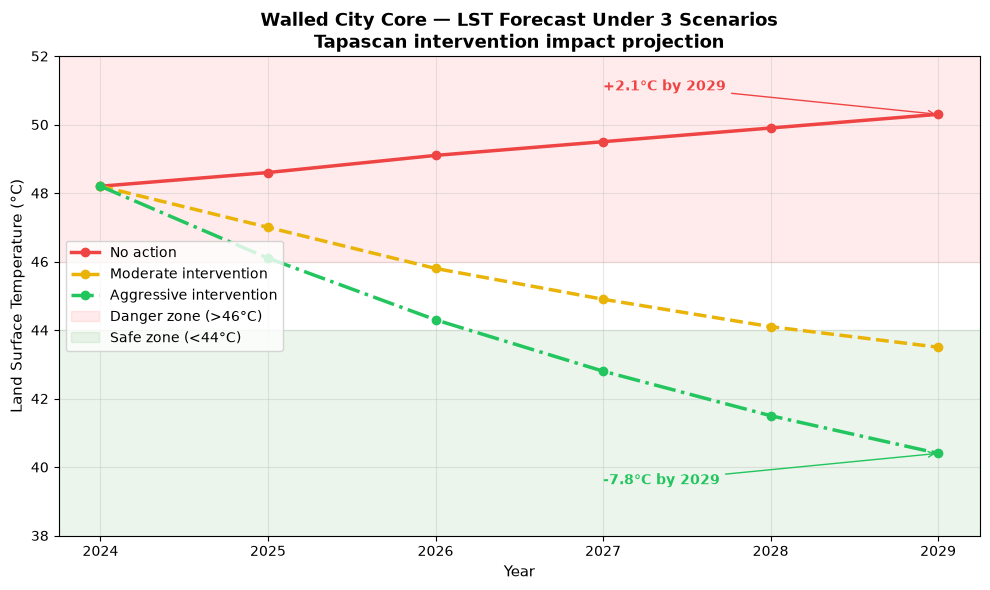

Chart saved


In [6]:
# Lesson 3 — Line Chart: Intervention Forecast

years = [2024, 2025, 2026, 2027, 2028, 2029]

# Three scenarios for Walled City (starts at 48.2°C)
no_action =      [48.2, 48.6, 49.1, 49.5, 49.9, 50.3]
moderate =       [48.2, 47.0, 45.8, 44.9, 44.1, 43.5]
aggressive =     [48.2, 46.1, 44.3, 42.8, 41.5, 40.4]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot three lines
ax.plot(years, no_action,  color="#EF4444", linewidth=2.5,
        marker="o", markersize=6, label="No action")
ax.plot(years, moderate,   color="#EAB308", linewidth=2.5,
        marker="o", markersize=6, linestyle="--", label="Moderate intervention")
ax.plot(years, aggressive, color="#22C55E", linewidth=2.5,
        marker="o", markersize=6, linestyle="-.", label="Aggressive intervention")

# Shade danger zone above 46°C
ax.axhspan(46, 52, alpha=0.08, color="red", label="Danger zone (>46°C)")

# Shade safe zone below 44°C
ax.axhspan(34, 44, alpha=0.08, color="green", label="Safe zone (<44°C)")

# Annotations
ax.annotate("-7.8°C by 2029", xy=(2029, 40.4),
            xytext=(2027, 39.5),
            arrowprops=dict(arrowstyle="->", color="#22C55E"),
            color="#22C55E", fontsize=10, fontweight="bold")

ax.annotate("+2.1°C by 2029", xy=(2029, 50.3),
            xytext=(2027, 51.0),
            arrowprops=dict(arrowstyle="->", color="#EF4444"),
            color="#EF4444", fontsize=10, fontweight="bold")

# Styling
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Land Surface Temperature (°C)", fontsize=11)
ax.set_title("Walled City Core — LST Forecast Under 3 Scenarios\n"
             "Tapascan intervention impact projection",
             fontsize=13, fontweight="bold")
ax.legend(loc="center left")
ax.set_ylim(38, 52)
ax.grid(True, alpha=0.3)
ax.set_xticks(years)

plt.tight_layout()
plt.savefig("intervention_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

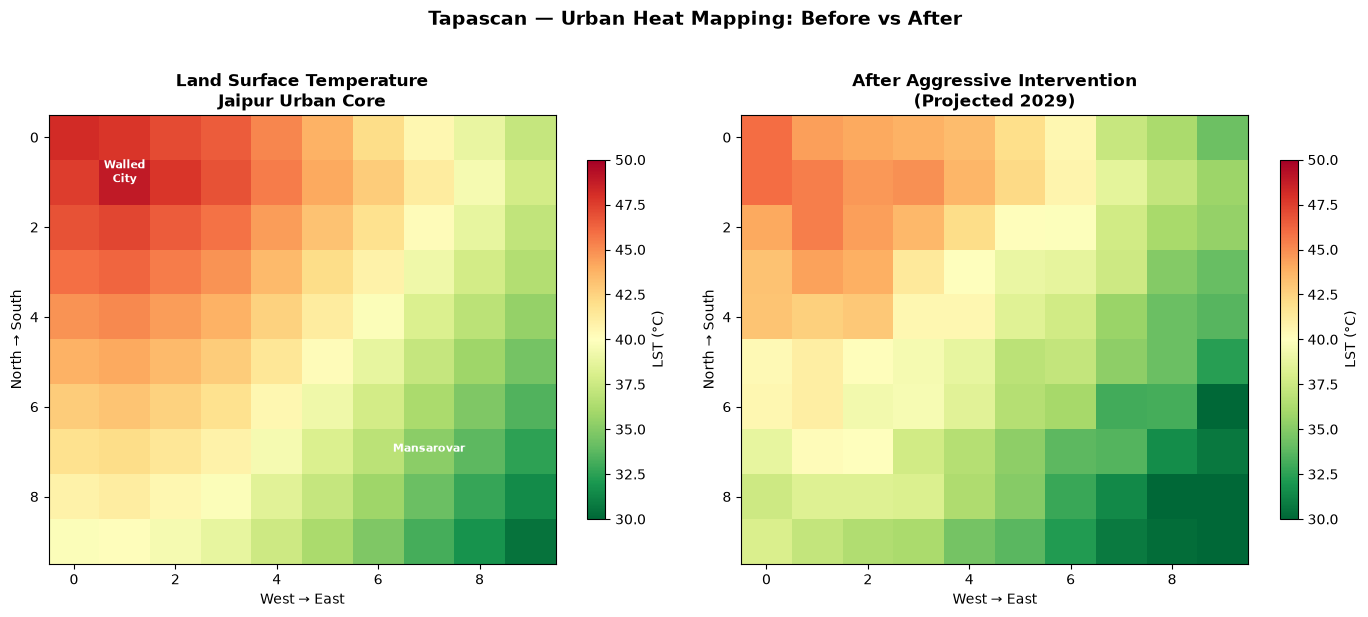

Chart saved


In [7]:
# Lesson 4 — Heatmap: Simulated LST Grid of Jaipur

# Simulate a 10x10 LST grid of Jaipur
np.random.seed(42)
lst_grid = np.array([
    [48.2, 47.8, 47.1, 46.5, 45.2, 43.8, 42.1, 40.5, 38.9, 37.2],
    [47.5, 48.9, 47.8, 46.8, 45.5, 44.1, 42.8, 41.2, 39.5, 37.8],
    [46.8, 47.2, 46.5, 45.8, 44.5, 43.2, 41.8, 40.2, 38.8, 37.1],
    [45.9, 46.2, 45.5, 44.8, 43.5, 42.1, 40.8, 39.2, 37.8, 36.5],
    [44.8, 45.1, 44.5, 43.8, 42.5, 41.2, 39.8, 38.2, 36.8, 35.5],
    [43.8, 44.1, 43.5, 42.8, 41.5, 40.2, 38.8, 37.2, 35.8, 34.5],
    [42.8, 43.1, 42.5, 41.8, 40.5, 39.2, 37.8, 36.2, 34.8, 33.5],
    [41.8, 42.1, 41.5, 40.8, 39.5, 38.2, 36.8, 35.2, 33.8, 32.5],
    [40.8, 41.1, 40.5, 39.8, 38.5, 37.2, 35.8, 34.2, 32.8, 31.5],
    [39.8, 40.1, 39.5, 38.8, 37.5, 36.2, 34.8, 33.2, 31.8, 30.5],
])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — LST heatmap
im1 = axes[0].imshow(lst_grid, cmap="RdYlGn_r", 
                      vmin=30, vmax=50, aspect="auto")
plt.colorbar(im1, ax=axes[0], label="LST (°C)", shrink=0.8)
axes[0].set_title("Land Surface Temperature\nJaipur Urban Core",
                   fontweight="bold")
axes[0].set_xlabel("West → East")
axes[0].set_ylabel("North → South")

# Add zone labels
axes[0].text(1, 1, "Walled\nCity", color="white", 
             fontsize=8, fontweight="bold", ha="center")
axes[0].text(7, 7, "Mansarovar", color="white",
             fontsize=8, fontweight="bold", ha="center")

# Right — After intervention heatmap
lst_after = lst_grid - np.random.uniform(1.5, 3.5, lst_grid.shape)
lst_after = np.clip(lst_after, 30, 50)

im2 = axes[1].imshow(lst_after, cmap="RdYlGn_r",
                      vmin=30, vmax=50, aspect="auto")
plt.colorbar(im2, ax=axes[1], label="LST (°C)", shrink=0.8)
axes[1].set_title("After Aggressive Intervention\n(Projected 2029)",
                   fontweight="bold")
axes[1].set_xlabel("West → East")
axes[1].set_ylabel("North → South")

# Main title
fig.suptitle("Tapascan — Urban Heat Mapping: Before vs After",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("heatmap_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")